# 04 - Full Generation Eval and Error Analysis

This notebook reruns generation evaluation over every held-out API-Bank eval example for the saved LoRA adapters from `02_train_eval.ipynb`.

It does not retrain. It expects adapter directories such as `checkpoints_A_seed42/adapter_D4` or `artifacts/partial/checkpoints_B_seed42/adapter_D4`. If adapter bundles are present as `.tar.gz`, the notebook can extract them before evaluation.

Outputs:
- `artifacts/full_eval_A_seed42.json`
- `artifacts/full_eval_B_seed42.json`
- `artifacts/full_eval_summary_seed42.json`
Report-ready outputs after evaluation:
- `artifacts/full_eval_report_metrics_seed42.json`
- `artifacts/full_eval_metrics_seed42.csv`
- `artifacts/full_eval_final_by_block_seed42.csv`
- `artifacts/full_eval_worst_apis_seed42.csv`
- `artifacts/full_eval_exact_full_heatmaps_seed42.png/.pdf`
- `artifacts/full_eval_name_accuracy_heatmaps_seed42.png/.pdf`
- `artifacts/full_eval_final_accuracy_by_block_seed42.png/.pdf`
- `artifacts/full_eval_error_categories_seed42.png/.pdf`

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Install dependencies

In [3]:
!pip install -q transformers accelerate peft bitsandbytes huggingface_hub tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 57.5 MB/s eta 0:00:00


## 2. Configuration and imports

In [4]:
import gc
import json
import os
import pickle
import random
import re
import tarfile
import time
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import torch
from tqdm.auto import tqdm


def find_repo_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]
    for candidate in candidates:
        if (candidate / "PROJECT_INFO.md").exists() and (candidate / "artifacts").exists():
            return candidate
        if (candidate / "artifacts" / "preprocessed_data.zip").exists():
            return candidate
    return Path.cwd()


ROOT = find_repo_root()
ARTIFACTS = ROOT / "artifacts"
PARTIAL = ARTIFACTS / "partial"

CONDITIONS = ["A", "B"]
SEED = 42
STAGES = [1, 2, 3, 4]

MAX_NEW_TOKENS = 128
EVAL_MAX_SAMPLES = None  # None means full eval over every scored eval example.
SAVE_PREDICTIONS = True

OUTPUT_DIR = ARTIFACTS
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT)
print("Conditions:", CONDITIONS)
print("Seed:", SEED)
print("Stages:", STAGES)
print("Eval max samples:", EVAL_MAX_SAMPLES)

Root: /content
Conditions: ['A', 'B']
Seed: 42
Stages: [1, 2, 3, 4]
Eval max samples: None


## 3. Load preprocessed API-Bank data

In [5]:
def load_preprocessed():
    candidates = [
        ROOT / "preprocessed_data" / "preprocessed.pkl",
        ROOT.parent / "preprocessed_data" / "preprocessed.pkl",
    ]
    for path in candidates:
        if path.exists():
            with open(path, "rb") as f:
                return pickle.load(f)

    zip_candidates = [
        ARTIFACTS / "preprocessed_data.zip",
        ROOT.parent / "artifacts" / "preprocessed_data.zip",
    ]
    for path in zip_candidates:
        if path.exists():
            with zipfile.ZipFile(path) as zf:
                with zf.open("preprocessed.pkl") as f:
                    return pickle.load(f)

    raise FileNotFoundError("Could not find preprocessed.pkl or artifacts/preprocessed_data.zip")

data = load_preprocessed()
blocks = data["blocks"]
config = data["config"]

MODEL_NAME = config["model_name"]
NUM_BLOCKS = config["num_blocks"]
MAX_SEQ_LEN = config["max_seq_len"]
SYSTEM_PROMPT = config["system_prompt"]

print("Model:", MODEL_NAME)
print("Blocks:", NUM_BLOCKS)
print("Max sequence length:", MAX_SEQ_LEN)
for block in blocks:
    print(
        f"D{block['block_id']}: eval={len(block['eval_entries_raw'])}, "
        f"train_tokens_A={block['train_tokens_a']:,}, "
        f"train_tokens_B={block['train_tokens_b']:,}, "
        f"ratio={block['token_ratio']:.3f}"
    )

Model: meta-llama/Llama-3.1-8B-Instruct
Blocks: 4
Max sequence length: 1024
D1: eval=175, train_tokens_A=470,317, train_tokens_B=586,733, ratio=1.248
D2: eval=175, train_tokens_A=471,362, train_tokens_B=587,908, ratio=1.247
D3: eval=171, train_tokens_A=454,303, train_tokens_B=569,510, ratio=1.254
D4: eval=175, train_tokens_A=461,187, train_tokens_B=580,163, ratio=1.258


## 4. Discover adapter checkpoints

In [6]:
def safe_extract_tar(tf, extract_root):
    extract_root = extract_root.resolve()
    for member in tf.getmembers():
        target = (extract_root / member.name).resolve()
        if target != extract_root and extract_root not in target.parents:
            raise ValueError(f"Unsafe tar member path: {member.name}")
    tf.extractall(extract_root)


def maybe_extract_adapter_bundle(condition, seed):
    tar_candidates = [
        PARTIAL / f"checkpoints_{condition}_seed{seed}.tar.gz",
        ARTIFACTS / f"checkpoints_{condition}_seed{seed}.tar.gz",
        ROOT / f"checkpoints_{condition}_seed{seed}.tar.gz",
        Path("/content") / f"checkpoints_{condition}_seed{seed}.tar.gz",
    ]

    for tar_path in tar_candidates:
        if not tar_path.exists():
            continue

        extract_root = PARTIAL
        target_root = extract_root / f"checkpoints_{condition}_seed{seed}"
        if target_root.exists():
            return target_root

        print(f"Extracting {tar_path} -> {extract_root}")
        extract_root.mkdir(parents=True, exist_ok=True)
        with tarfile.open(tar_path, "r:gz") as tf:
            safe_extract_tar(tf, extract_root)
        return target_root

    return None


def adapter_candidates(condition, seed, stage):
    roots = [
        ROOT / f"checkpoints_{condition}_seed{seed}",
        PARTIAL / f"checkpoints_{condition}_seed{seed}",
        ARTIFACTS / f"checkpoints_{condition}_seed{seed}",
        Path("/content") / f"checkpoints_{condition}_seed{seed}",
        Path("/content/drive/MyDrive") / f"checkpoints_{condition}_seed{seed}",
    ]
    return [root / f"adapter_D{stage}" for root in roots]


def find_adapter_path(condition, seed, stage):
    maybe_extract_adapter_bundle(condition, seed)
    for path in adapter_candidates(condition, seed, stage):
        if (path / "adapter_config.json").exists():
            return path
    return None


adapter_manifest = {}
missing_adapters = []

for condition in CONDITIONS:
    adapter_manifest[condition] = {}
    for stage in STAGES:
        path = find_adapter_path(condition, SEED, stage)
        adapter_manifest[condition][stage] = str(path) if path else None
        if path is None:
            missing_adapters.append((condition, stage))

print(json.dumps(adapter_manifest, indent=2))

if missing_adapters:
    print("\nMissing adapters:")
    for condition, stage in missing_adapters:
        print(f"  {condition} adapter_D{stage}")
    print("\nFull eval requires the saved LoRA adapters. Upload or extract checkpoint bundles, then rerun this cell.")
else:
    print("\nAll requested adapters found.")

Extracting /content/checkpoints_A_seed42.tar.gz -> /content/artifacts/partial


/tmp/ipykernel_4371/3117392321.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(extract_root)


Extracting /content/checkpoints_B_seed42.tar.gz -> /content/artifacts/partial
{
  "A": {
    "1": "/content/artifacts/partial/checkpoints_A_seed42/adapter_D1",
    "2": "/content/artifacts/partial/checkpoints_A_seed42/adapter_D2",
    "3": "/content/artifacts/partial/checkpoints_A_seed42/adapter_D3",
    "4": "/content/artifacts/partial/checkpoints_A_seed42/adapter_D4"
  },
  "B": {
    "1": "/content/artifacts/partial/checkpoints_B_seed42/adapter_D1",
    "2": "/content/artifacts/partial/checkpoints_B_seed42/adapter_D2",
    "3": "/content/artifacts/partial/checkpoints_B_seed42/adapter_D3",
    "4": "/content/artifacts/partial/checkpoints_B_seed42/adapter_D4"
  }
}

All requested adapters found.


## 5. Load tokenizer and base model helper

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel


def get_hf_token():
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")
    if token:
        return token

    try:
        from google.colab import userdata
        return userdata.get("HF_TOKEN")
    except Exception:
        return None


HF_TOKEN = get_hf_token()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def load_model_with_adapter(adapter_path):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        token=HF_TOKEN,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        attn_implementation="sdpa",
    )
    model = PeftModel.from_pretrained(base, adapter_path)
    model.eval()
    return model


print("Tokenizer loaded:", tokenizer.__class__.__name__)

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Tokenizer loaded: TokenizersBackend


## 6. Prompting and API-call scoring

In [8]:
def strip_trajectory_lines(text):
    lines = []
    for line in text.split("\n"):
        s = line.strip()
        if s.startswith("API-Request:") or s.startswith("API-Response:"):
            continue
        if "Received API Response" in line or "Generate API Request" in line:
            continue
        lines.append(line)
    return "\n".join(lines).strip()


CALL_RE = re.compile(r"\[\s*([A-Za-z_][A-Za-z0-9_]*)\((.*?)\)\s*\]", re.DOTALL)
PARAM_RE = re.compile(r"(\w+)='([^']*)'")


def build_generation_prompt(entry, condition):
    if condition == "A":
        context = strip_trajectory_lines(entry["input"])
    else:
        context = entry["input"]

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": context},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


def parse_api_call(text):
    match = CALL_RE.search(text or "")
    if not match:
        return None, {}
    api_name = match.group(1)
    params = {k: v for k, v in PARAM_RE.findall(match.group(2))}
    return api_name, params


def normalize_params(params):
    return {str(k).strip().lower(): str(v).strip().lower() for k, v in (params or {}).items()}


def classify_prediction(expected_api, expected_params, pred_api, pred_params):
    expected_params = normalize_params(expected_params)
    pred_params = normalize_params(pred_params)

    if pred_api is None:
        return "malformed_or_no_call"

    name_correct = pred_api.lower() == expected_api.lower()
    if not name_correct:
        return "wrong_api"

    if pred_params == expected_params:
        return "exact_full_call"

    overlap = set(expected_params.items()) & set(pred_params.items())
    if overlap:
        return "correct_api_some_params"

    return "correct_api_wrong_params"


def summarize_rows(rows):
    total = len(rows)
    if total == 0:
        return {
            "total": 0,
            "name_acc": 0.0,
            "exact_full_acc": 0.0,
            "name_plus_any_param_acc": 0.0,
            "malformed_rate": 0.0,
            "categories": {},
            "per_api": {},
        }

    categories = Counter(row["category"] for row in rows)
    per_api_counts = defaultdict(Counter)
    for row in rows:
        per_api_counts[row["expected_api"]][row["category"]] += 1
        per_api_counts[row["expected_api"]]["total"] += 1

    per_api = {}
    for api, counts in per_api_counts.items():
        api_total = counts["total"]
        per_api[api] = {
            "total": api_total,
            "name_acc": (
                counts["exact_full_call"]
                + counts["correct_api_some_params"]
                + counts["correct_api_wrong_params"]
            ) / api_total,
            "exact_full_acc": counts["exact_full_call"] / api_total,
            "categories": dict(counts),
        }

    name_correct = (
        categories["exact_full_call"]
        + categories["correct_api_some_params"]
        + categories["correct_api_wrong_params"]
    )
    name_plus_any_param = categories["exact_full_call"] + categories["correct_api_some_params"]

    return {
        "total": total,
        "name_acc": name_correct / total,
        "exact_full_acc": categories["exact_full_call"] / total,
        "name_plus_any_param_acc": name_plus_any_param / total,
        "malformed_rate": categories["malformed_or_no_call"] / total,
        "categories": dict(categories),
        "per_api": per_api,
    }

## 7. Full generation evaluation functions

In [9]:
@torch.no_grad()
def generate_one(model, prompt):
    enc = tokenizer(
        prompt,
        truncation=True,
        max_length=MAX_SEQ_LEN - MAX_NEW_TOKENS,
        return_tensors="pt",
    ).to(model.device)

    gen = model.generate(
        **enc,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

    return tokenizer.decode(
        gen[0][enc["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )


@torch.no_grad()
def evaluate_block(model, entries, condition, block_id, stage, sample_limit=None):
    scored = []
    for entry_index, entry in enumerate(entries):
        expected_api, expected_params = parse_api_call(entry.get("output", ""))
        if expected_api is None:
            continue
        scored.append((entry_index, entry, expected_api, normalize_params(expected_params)))

    if sample_limit is not None and len(scored) > sample_limit:
        rng = random.Random(20_000 + stage * 100 + block_id)
        keep = sorted(rng.sample(range(len(scored)), sample_limit))
        scored = [scored[i] for i in keep]

    rows = []
    iterator = tqdm(scored, desc=f"{condition} D{stage} -> eval D{block_id}", leave=False)

    for entry_index, entry, expected_api, expected_params in iterator:
        prompt = build_generation_prompt(entry, condition)
        generated = generate_one(model, prompt)
        pred_api, pred_params = parse_api_call(generated)
        pred_params_norm = normalize_params(pred_params)
        category = classify_prediction(expected_api, expected_params, pred_api, pred_params_norm)

        rows.append({
            "condition": condition,
            "seed": SEED,
            "train_stage": stage,
            "eval_block": block_id,
            "entry_index": entry_index,
            "entry_api_name": entry.get("api_name"),
            "expected_api": expected_api,
            "expected_params": expected_params,
            "pred_api": pred_api,
            "pred_params": pred_params_norm,
            "category": category,
            "generated": generated,
        })

    return summarize_rows(rows), rows

## 8. Run full evaluation

In [10]:
full_outputs = {}
summary_outputs = {
    "seed": SEED,
    "model": MODEL_NAME,
    "max_seq_len": MAX_SEQ_LEN,
    "max_new_tokens": MAX_NEW_TOKENS,
    "eval_max_samples": EVAL_MAX_SAMPLES,
    "conditions": {},
}

for condition in CONDITIONS:
    condition_result = {
        "condition": condition,
        "seed": SEED,
        "model": MODEL_NAME,
        "stages": {},
    }

    for stage in STAGES:
        adapter_path_str = adapter_manifest.get(condition, {}).get(stage)
        if adapter_path_str is None:
            print(f"Skipping {condition} adapter_D{stage}: adapter not found")
            continue

        adapter_path = Path(adapter_path_str)
        print(f"\nLoading {condition} adapter_D{stage}: {adapter_path}")
        model = load_model_with_adapter(adapter_path)

        stage_result = {
            "adapter_path": str(adapter_path),
            "eval_blocks": {},
        }
        started = time.time()

        for block in blocks:
            block_id = block["block_id"]
            metrics, rows = evaluate_block(
                model=model,
                entries=block["eval_entries_raw"],
                condition=condition,
                block_id=block_id,
                stage=stage,
                sample_limit=EVAL_MAX_SAMPLES,
            )
            stage_result["eval_blocks"][str(block_id)] = {
                "metrics": metrics,
                "predictions": rows if SAVE_PREDICTIONS else None,
            }
            print(
                f"{condition} D{stage} -> eval D{block_id}: "
                f"name={metrics['name_acc']:.3f}, "
                f"exact_full={metrics['exact_full_acc']:.3f}, "
                f"any_param={metrics['name_plus_any_param_acc']:.3f}, "
                f"n={metrics['total']}"
            )

        stage_result["runtime_seconds"] = time.time() - started
        condition_result["stages"][str(stage)] = stage_result

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        out_path = OUTPUT_DIR / f"full_eval_{condition}_seed{SEED}.json"
        with open(out_path, "w") as f:
            json.dump(condition_result, f, indent=2)
        print(f"Saved partial/full condition result: {out_path}")

    full_outputs[condition] = condition_result

    summary_outputs["conditions"][condition] = {
        "stages": {
            stage: {
                "eval_blocks": {
                    block_id: payload["metrics"]
                    for block_id, payload in stage_payload["eval_blocks"].items()
                },
                "runtime_seconds": stage_payload.get("runtime_seconds"),
                "adapter_path": stage_payload.get("adapter_path"),
            }
            for stage, stage_payload in condition_result["stages"].items()
        }
    }

summary_path = OUTPUT_DIR / f"full_eval_summary_seed{SEED}.json"
with open(summary_path, "w") as f:
    json.dump(summary_outputs, f, indent=2)

print(f"\nSaved summary: {summary_path}")

# Persist full-eval outputs to Google Drive when running in Colab.
# These JSONs contain the expensive regenerated predictions; keep a Drive copy
# so they survive Colab runtime resets.
try:
    from google.colab import drive
    import shutil
    from pathlib import Path

    drive.mount('/content/drive', force_remount=False)
    drive_dir = Path('/content/drive/MyDrive/590NN_Final_Project')
    drive_dir.mkdir(parents=True, exist_ok=True)

    copied = []
    for path in sorted(OUTPUT_DIR.glob(f"full_eval_*_seed{SEED}.json")):
        target = drive_dir / path.name
        shutil.copy2(path, target)
        copied.append(str(target))

    print("Saved full-eval outputs to Drive:")
    for target in copied:
        print(f"  {target}")
except ModuleNotFoundError:
    print("Google Colab not detected; skipping Drive backup.")
except Exception as exc:
    print(f"Drive backup failed: {exc}")
    raise


Loading A adapter_D1: /content/artifacts/partial/checkpoints_A_seed42/adapter_D1


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

B D4 -> eval D2: name=0.827, exact_full=0.615, any_param=0.769, n=104


B D4 -> eval D3:   0%|          | 0/103 [00:00<?, ?it/s]

B D4 -> eval D3: name=0.670, exact_full=0.447, any_param=0.612, n=103


B D4 -> eval D4:   0%|          | 0/107 [00:00<?, ?it/s]

B D4 -> eval D4: name=0.738, exact_full=0.636, any_param=0.720, n=107
Saved partial/full condition result: /content/artifacts/full_eval_B_seed42.json

Saved summary: /content/artifacts/full_eval_summary_seed42.json
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved full-eval outputs to Drive:
  /content/drive/MyDrive/590NN_Final_Project/full_eval_A_seed42.json
  /content/drive/MyDrive/590NN_Final_Project/full_eval_B_seed42.json
  /content/drive/MyDrive/590NN_Final_Project/full_eval_summary_seed42.json


## 9. Build full-eval matrices

In [11]:
def matrix_from_condition(condition_summary, metric_key="exact_full_acc"):
    stages = sorted(int(s) for s in condition_summary["stages"].keys())
    matrix = []
    for stage in stages:
        row = []
        eval_blocks = condition_summary["stages"][str(stage)]["eval_blocks"]
        for block_id in range(1, NUM_BLOCKS + 1):
            row.append(eval_blocks[str(block_id)][metric_key])
        matrix.append(row)
    return matrix


for condition in CONDITIONS:
    condition_summary = summary_outputs["conditions"].get(condition, {})
    if not condition_summary.get("stages"):
        print(f"No full-eval stages for condition {condition}")
        continue

    exact = matrix_from_condition(condition_summary, "exact_full_acc")
    name = matrix_from_condition(condition_summary, "name_acc")
    any_param = matrix_from_condition(condition_summary, "name_plus_any_param_acc")

    print(f"\nCondition {condition} exact full-call matrix")
    print(np.array(exact))

    print(f"Condition {condition} name accuracy matrix")
    print(np.array(name))

    print(f"Condition {condition} name plus any-param matrix")
    print(np.array(any_param))


Condition A exact full-call matrix
[[0.47619048 0.36538462 0.32038835 0.25233645]
 [0.42063492 0.55769231 0.30097087 0.28037383]
 [0.3968254  0.45192308 0.41747573 0.27102804]
 [0.35714286 0.43269231 0.32038835 0.45794393]]
Condition A name accuracy matrix
[[0.87301587 0.60576923 0.54368932 0.56074766]
 [0.74603175 0.84615385 0.49514563 0.56074766]
 [0.6984127  0.65384615 0.69902913 0.61682243]
 [0.64285714 0.625      0.60194175 0.79439252]]
Condition A name plus any-param matrix
[[0.72222222 0.48076923 0.45631068 0.43925234]
 [0.61111111 0.75961538 0.41747573 0.48598131]
 [0.56349206 0.59615385 0.61165049 0.53271028]
 [0.51587302 0.56730769 0.50485437 0.65420561]]

Condition B exact full-call matrix
[[0.61111111 0.57692308 0.42718447 0.43925234]
 [0.55555556 0.67307692 0.45631068 0.4953271 ]
 [0.52380952 0.625      0.53398058 0.51401869]
 [0.57936508 0.61538462 0.44660194 0.63551402]]
Condition B name accuracy matrix
[[0.72222222 0.84615385 0.66019417 0.75700935]
 [0.71428571 0.84615

## 10. Report-ready exports

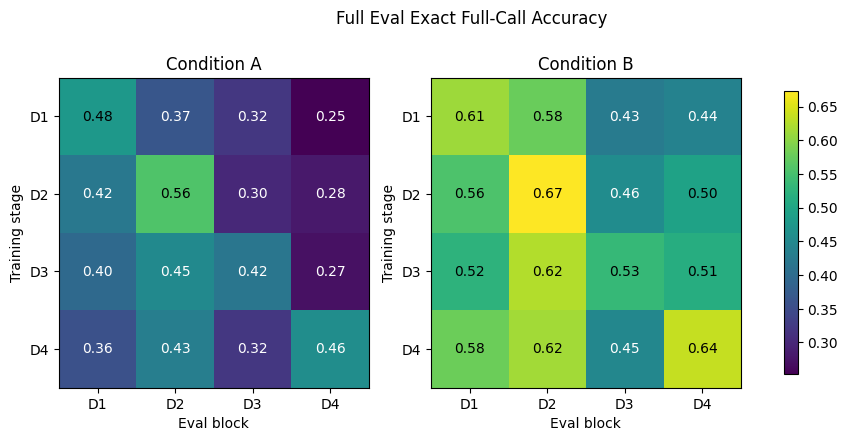

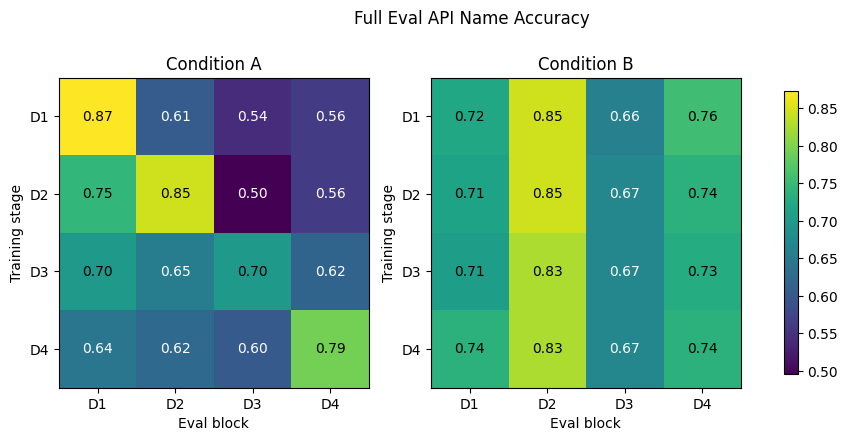

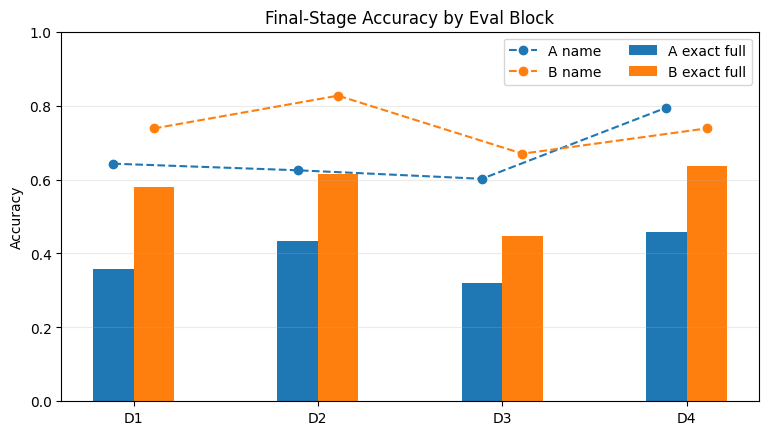

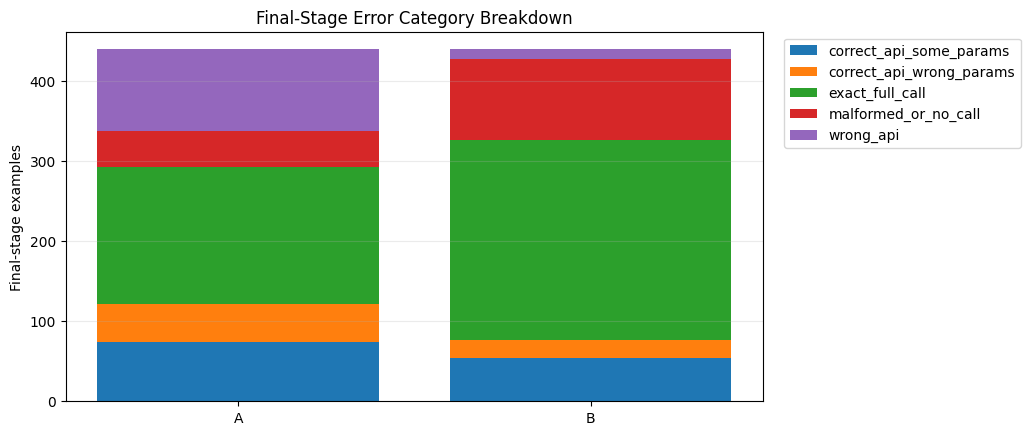

Report-ready files:
  /content/artifacts/full_eval_metrics_seed42.csv
  /content/artifacts/full_eval_final_by_block_seed42.csv
  /content/artifacts/full_eval_worst_apis_seed42.csv
  /content/artifacts/full_eval_report_metrics_seed42.json
  /content/artifacts/full_eval_exact_full_heatmaps_seed42.png
  /content/artifacts/full_eval_exact_full_heatmaps_seed42.pdf
  /content/artifacts/full_eval_name_accuracy_heatmaps_seed42.png
  /content/artifacts/full_eval_name_accuracy_heatmaps_seed42.pdf
  /content/artifacts/full_eval_final_accuracy_by_block_seed42.png
  /content/artifacts/full_eval_final_accuracy_by_block_seed42.pdf
  /content/artifacts/full_eval_error_categories_seed42.png
  /content/artifacts/full_eval_error_categories_seed42.pdf
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied report-ready files to Drive:
  /content/drive/MyDrive/590NN_Final_Project/full_eval_metrics_seed42.csv
  /content/drive/My

In [12]:
import csv
import math

import matplotlib.pyplot as plt

REPORT_PREFIX = f"full_eval"
REPORT_OUTPUTS = []


def _safe_get_condition_summary(condition):
    return summary_outputs.get("conditions", {}).get(condition, {"stages": {}})


def _stage_numbers(condition_summary):
    return sorted(int(s) for s in condition_summary.get("stages", {}).keys())


def _metric_rows():
    rows = []
    for condition in CONDITIONS:
        condition_summary = _safe_get_condition_summary(condition)
        for stage in _stage_numbers(condition_summary):
            eval_blocks = condition_summary["stages"][str(stage)]["eval_blocks"]
            for block_id in range(1, NUM_BLOCKS + 1):
                metrics = eval_blocks[str(block_id)]
                rows.append({
                    "condition": condition,
                    "train_stage": stage,
                    "eval_block": block_id,
                    "total": metrics["total"],
                    "name_acc": metrics["name_acc"],
                    "exact_full_acc": metrics["exact_full_acc"],
                    "name_plus_any_param_acc": metrics["name_plus_any_param_acc"],
                    "malformed_rate": metrics["malformed_rate"],
                    "categories_json": json.dumps(metrics.get("categories", {}), sort_keys=True),
                })
    return rows


metrics_rows = _metric_rows()
metrics_csv = OUTPUT_DIR / f"full_eval_metrics_seed{SEED}.csv"
with open(metrics_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(metrics_rows[0].keys()) if metrics_rows else [])
    if metrics_rows:
        writer.writeheader()
        writer.writerows(metrics_rows)
REPORT_OUTPUTS.append(metrics_csv)


final_rows = []
for condition in CONDITIONS:
    condition_summary = _safe_get_condition_summary(condition)
    stages = _stage_numbers(condition_summary)
    if not stages:
        continue
    final_stage = stages[-1]
    eval_blocks = condition_summary["stages"][str(final_stage)]["eval_blocks"]
    for block_id in range(1, NUM_BLOCKS + 1):
        metrics = eval_blocks[str(block_id)]
        final_rows.append({
            "condition": condition,
            "final_stage": final_stage,
            "eval_block": block_id,
            "total": metrics["total"],
            "name_acc": metrics["name_acc"],
            "exact_full_acc": metrics["exact_full_acc"],
            "name_plus_any_param_acc": metrics["name_plus_any_param_acc"],
            "malformed_rate": metrics["malformed_rate"],
        })

final_csv = OUTPUT_DIR / f"full_eval_final_by_block_seed{SEED}.csv"
with open(final_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(final_rows[0].keys()) if final_rows else [])
    if final_rows:
        writer.writeheader()
        writer.writerows(final_rows)
REPORT_OUTPUTS.append(final_csv)


worst_rows = []
for condition in CONDITIONS:
    condition_summary = _safe_get_condition_summary(condition)
    stages = _stage_numbers(condition_summary)
    if not stages:
        continue
    final_stage = stages[-1]
    for block_id in range(1, NUM_BLOCKS + 1):
        metrics = condition_summary["stages"][str(final_stage)]["eval_blocks"][str(block_id)]
        for api, api_metrics in metrics.get("per_api", {}).items():
            worst_rows.append({
                "condition": condition,
                "final_stage": final_stage,
                "eval_block": block_id,
                "api": api,
                "total": api_metrics["total"],
                "name_acc": api_metrics["name_acc"],
                "exact_full_acc": api_metrics["exact_full_acc"],
                "categories_json": json.dumps(api_metrics.get("categories", {}), sort_keys=True),
            })
worst_rows.sort(key=lambda r: (r["exact_full_acc"], r["name_acc"], -r["total"], r["condition"], r["eval_block"], r["api"]))

worst_csv = OUTPUT_DIR / f"full_eval_worst_apis_seed{SEED}.csv"
with open(worst_csv, "w", newline="") as f:
    fieldnames = list(worst_rows[0].keys()) if worst_rows else [
        "condition", "final_stage", "eval_block", "api", "total", "name_acc", "exact_full_acc", "categories_json"
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(worst_rows)
REPORT_OUTPUTS.append(worst_csv)


report_metrics = {
    "seed": SEED,
    "model": MODEL_NAME,
    "max_seq_len": MAX_SEQ_LEN,
    "max_new_tokens": MAX_NEW_TOKENS,
    "eval_max_samples": EVAL_MAX_SAMPLES,
    "conditions": {},
}

for condition in CONDITIONS:
    condition_summary = _safe_get_condition_summary(condition)
    stages = _stage_numbers(condition_summary)
    if not stages:
        continue
    final_stage = stages[-1]
    final_metrics = condition_summary["stages"][str(final_stage)]["eval_blocks"]
    final_exact = [final_metrics[str(i)]["exact_full_acc"] for i in range(1, NUM_BLOCKS + 1)]
    final_name = [final_metrics[str(i)]["name_acc"] for i in range(1, NUM_BLOCKS + 1)]
    final_any = [final_metrics[str(i)]["name_plus_any_param_acc"] for i in range(1, NUM_BLOCKS + 1)]
    final_malformed = [final_metrics[str(i)]["malformed_rate"] for i in range(1, NUM_BLOCKS + 1)]

    category_totals = Counter()
    for block_metrics in final_metrics.values():
        category_totals.update(block_metrics.get("categories", {}))

    report_metrics["conditions"][condition] = {
        "final_stage": final_stage,
        "final_exact_full_by_block": final_exact,
        "final_name_acc_by_block": final_name,
        "final_name_plus_any_param_by_block": final_any,
        "final_malformed_rate_by_block": final_malformed,
        "final_exact_full_mean": float(np.mean(final_exact)),
        "final_name_acc_mean": float(np.mean(final_name)),
        "final_name_plus_any_param_mean": float(np.mean(final_any)),
        "final_malformed_rate_mean": float(np.mean(final_malformed)),
        "final_category_totals": dict(category_totals),
    }

if all(c in report_metrics["conditions"] for c in ("A", "B")):
    report_metrics["comparison"] = {
        "B_minus_A_final_exact_full_mean": (
            report_metrics["conditions"]["B"]["final_exact_full_mean"]
            - report_metrics["conditions"]["A"]["final_exact_full_mean"]
        ),
        "B_minus_A_final_name_acc_mean": (
            report_metrics["conditions"]["B"]["final_name_acc_mean"]
            - report_metrics["conditions"]["A"]["final_name_acc_mean"]
        ),
        "B_minus_A_final_any_param_mean": (
            report_metrics["conditions"]["B"]["final_name_plus_any_param_mean"]
            - report_metrics["conditions"]["A"]["final_name_plus_any_param_mean"]
        ),
    }

report_json = OUTPUT_DIR / f"full_eval_report_metrics_seed{SEED}.json"
with open(report_json, "w") as f:
    json.dump(report_metrics, f, indent=2)
REPORT_OUTPUTS.append(report_json)


def _savefig(fig, stem):
    png = OUTPUT_DIR / f"{stem}_seed{SEED}.png"
    pdf = OUTPUT_DIR / f"{stem}_seed{SEED}.pdf"
    fig.savefig(png, dpi=180, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    REPORT_OUTPUTS.extend([png, pdf])
    plt.show()


def _plot_heatmaps(metric_key, stem, title):
    available = [c for c in CONDITIONS if _safe_get_condition_summary(c).get("stages")]
    if not available:
        print(f"No data for {title}; skipping.")
        return

    fig, axes = plt.subplots(1, len(available), figsize=(5.5 * len(available), 4.6), squeeze=False)
    matrices = []
    for condition in available:
        matrix = np.array(matrix_from_condition(_safe_get_condition_summary(condition), metric_key))
        matrices.append(matrix)
    vmax = max(float(np.nanmax(m)) for m in matrices)
    vmin = min(float(np.nanmin(m)) for m in matrices)

    for ax, condition, matrix in zip(axes[0], available, matrices):
        im = ax.imshow(matrix, vmin=vmin, vmax=vmax, cmap="viridis")
        ax.set_title(f"Condition {condition}")
        ax.set_xlabel("Eval block")
        ax.set_ylabel("Training stage")
        ax.set_xticks(range(NUM_BLOCKS), [f"D{i}" for i in range(1, NUM_BLOCKS + 1)])
        ax.set_yticks(range(matrix.shape[0]), [f"D{i}" for i in range(1, matrix.shape[0] + 1)])
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="white" if matrix[i, j] < (vmin + vmax) / 2 else "black")
    fig.suptitle(title)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    _savefig(fig, stem)


_plot_heatmaps("exact_full_acc", "full_eval_exact_full_heatmaps", "Full Eval Exact Full-Call Accuracy")
_plot_heatmaps("name_acc", "full_eval_name_accuracy_heatmaps", "Full Eval API Name Accuracy")


if final_rows:
    block_ids = list(range(1, NUM_BLOCKS + 1))
    x = np.arange(len(block_ids))
    width = 0.22
    fig, ax = plt.subplots(figsize=(9, 4.8))
    offsets = {"A": -width / 2, "B": width / 2}
    for condition in CONDITIONS:
        rows = [r for r in final_rows if r["condition"] == condition]
        if not rows:
            continue
        rows.sort(key=lambda r: r["eval_block"])
        ax.bar(x + offsets.get(condition, 0), [r["exact_full_acc"] for r in rows], width, label=f"{condition} exact full")
        ax.plot(x + offsets.get(condition, 0), [r["name_acc"] for r in rows], marker="o", linestyle="--", label=f"{condition} name")
    ax.set_xticks(x, [f"D{i}" for i in block_ids])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title("Final-Stage Accuracy by Eval Block")
    ax.legend(ncol=2)
    ax.grid(axis="y", alpha=0.25)
    _savefig(fig, "full_eval_final_accuracy_by_block")


if any(report_metrics["conditions"].get(c, {}).get("final_category_totals") for c in CONDITIONS):
    categories = sorted({
        category
        for c in CONDITIONS
        for category in report_metrics["conditions"].get(c, {}).get("final_category_totals", {}).keys()
    })
    fig, ax = plt.subplots(figsize=(9, 4.8))
    bottoms = np.zeros(len(CONDITIONS))
    x = np.arange(len(CONDITIONS))
    for category in categories:
        vals = np.array([
            report_metrics["conditions"].get(c, {}).get("final_category_totals", {}).get(category, 0)
            for c in CONDITIONS
        ])
        ax.bar(x, vals, bottom=bottoms, label=category)
        bottoms += vals
    ax.set_xticks(x, CONDITIONS)
    ax.set_ylabel("Final-stage examples")
    ax.set_title("Final-Stage Error Category Breakdown")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.grid(axis="y", alpha=0.25)
    _savefig(fig, "full_eval_error_categories")


print("Report-ready files:")
for path in REPORT_OUTPUTS:
    print(f"  {path}")

try:
    from google.colab import drive
    import shutil
    from pathlib import Path

    drive.mount('/content/drive', force_remount=False)
    drive_dir = Path('/content/drive/MyDrive/590NN_Final_Project')
    drive_dir.mkdir(parents=True, exist_ok=True)
    for path in REPORT_OUTPUTS:
        shutil.copy2(path, drive_dir / path.name)
    print("Copied report-ready files to Drive:")
    for path in REPORT_OUTPUTS:
        print(f"  {drive_dir / path.name}")
except ModuleNotFoundError:
    print("Google Colab not detected; skipping Drive backup.")
except Exception as exc:
    print(f"Drive backup failed: {exc}")
    raise


## 11. Inspect errors

In [13]:
def worst_apis(condition, stage, block_id, top_k=10):
    stage_payload = full_outputs[condition]["stages"][str(stage)]
    block_payload = stage_payload["eval_blocks"][str(block_id)]
    per_api = block_payload["metrics"]["per_api"]
    rows = []
    for api, metrics in per_api.items():
        rows.append((api, metrics["total"], metrics["exact_full_acc"], metrics["name_acc"]))
    rows.sort(key=lambda x: (x[2], x[3], -x[1]))
    return rows[:top_k]


def show_errors(condition, stage, block_id, category=None, limit=10):
    rows = full_outputs[condition]["stages"][str(stage)]["eval_blocks"][str(block_id)]["predictions"]
    shown = 0
    for row in rows:
        if category is not None and row["category"] != category:
            continue
        print("-" * 80)
        print("category:", row["category"])
        print("expected:", row["expected_api"], row["expected_params"])
        print("predicted:", row["pred_api"], row["pred_params"])
        print("generated:", row["generated"][:500])
        shown += 1
        if shown >= limit:
            break


# Example after running evaluation:
# worst_apis("B", stage=4, block_id=4)
# show_errors("B", stage=4, block_id=3, category="wrong_api", limit=5)